In [2]:
import qsharp
import random
import json
import time
from diskcache import Cache
from matplotlib import pyplot as plt

cache = Cache("~/quant-arith-cache/re-multipliers")
qsharp.init(project_root="../")

@cache.memoize()
def estimate_resources_multiply(op, n):
    est = qsharp.estimate(f"EstimateUtils.RunMultiply({n},{op})")
    return json.dumps(est)    

2 QuantumArithmetic.CG2019.MultiplySchoolbook 0.0005085468292236328
3 QuantumArithmetic.CG2019.MultiplySchoolbook 0.00047016143798828125
4 QuantumArithmetic.CG2019.MultiplySchoolbook 0.0005662441253662109
5 QuantumArithmetic.CG2019.MultiplySchoolbook 0.0002543926239013672
6 QuantumArithmetic.CG2019.MultiplySchoolbook 0.00022268295288085938
7 QuantumArithmetic.CG2019.MultiplySchoolbook 0.0005075931549072266
8 QuantumArithmetic.CG2019.MultiplySchoolbook 0.000274658203125
10 QuantumArithmetic.CG2019.MultiplySchoolbook 0.000286102294921875
11 QuantumArithmetic.CG2019.MultiplySchoolbook 0.0001780986785888672
13 QuantumArithmetic.CG2019.MultiplySchoolbook 0.0002281665802001953
16 QuantumArithmetic.CG2019.MultiplySchoolbook 0.000438690185546875
19 QuantumArithmetic.CG2019.MultiplySchoolbook 0.00027561187744140625
23 QuantumArithmetic.CG2019.MultiplySchoolbook 0.0002689361572265625
27 QuantumArithmetic.CG2019.MultiplySchoolbook 0.00023865699768066406
32 QuantumArithmetic.CG2019.MultiplySchoolb

181 QuantumArithmetic.CG2019.MultiplyKaratsuba 0.00023746490478515625
215 QuantumArithmetic.CG2019.MultiplyKaratsuba 0.00023293495178222656
256 QuantumArithmetic.CG2019.MultiplyKaratsuba 0.0001583099365234375
304 QuantumArithmetic.CG2019.MultiplyKaratsuba 0.00024247169494628906
362 QuantumArithmetic.CG2019.MultiplyKaratsuba 0.00030541419982910156
431 QuantumArithmetic.CG2019.MultiplyKaratsuba 0.0002665519714355469
512 QuantumArithmetic.CG2019.MultiplyKaratsuba 0.00024056434631347656
609 QuantumArithmetic.CG2019.MultiplyKaratsuba 0.0002338886260986328
724 QuantumArithmetic.CG2019.MultiplyKaratsuba 0.0001544952392578125
861 QuantumArithmetic.CG2019.MultiplyKaratsuba 0.0002663135528564453
1024 QuantumArithmetic.CG2019.MultiplyKaratsuba 0.00021028518676757812
1218 QuantumArithmetic.CG2019.MultiplyKaratsuba 0.00022125244140625
1448 QuantumArithmetic.CG2019.MultiplyKaratsuba 0.00021791458129882812
1722 QuantumArithmetic.CG2019.MultiplyKaratsuba 0.00034546852111816406
2048 QuantumArithmetic.C

7 QuantumArithmetic.OFOSG2023.MultiplyWallaceTree 0.00020122528076171875
8 QuantumArithmetic.OFOSG2023.MultiplyWallaceTree 0.0002148151397705078
10 QuantumArithmetic.OFOSG2023.MultiplyWallaceTree 0.00021004676818847656
11 QuantumArithmetic.OFOSG2023.MultiplyWallaceTree 0.0001513957977294922
13 QuantumArithmetic.OFOSG2023.MultiplyWallaceTree 0.00022602081298828125
16 QuantumArithmetic.OFOSG2023.MultiplyWallaceTree 0.00014090538024902344
19 QuantumArithmetic.OFOSG2023.MultiplyWallaceTree 0.00024318695068359375
23 QuantumArithmetic.OFOSG2023.MultiplyWallaceTree 0.0001354217529296875
27 QuantumArithmetic.OFOSG2023.MultiplyWallaceTree 0.0002646446228027344
32 QuantumArithmetic.OFOSG2023.MultiplyWallaceTree 0.0001418590545654297
38 QuantumArithmetic.OFOSG2023.MultiplyWallaceTree 0.00023365020751953125
45 QuantumArithmetic.OFOSG2023.MultiplyWallaceTree 0.00021505355834960938
54 QuantumArithmetic.OFOSG2023.MultiplyWallaceTree 0.00013446807861328125
64 QuantumArithmetic.OFOSG2023.MultiplyWallac

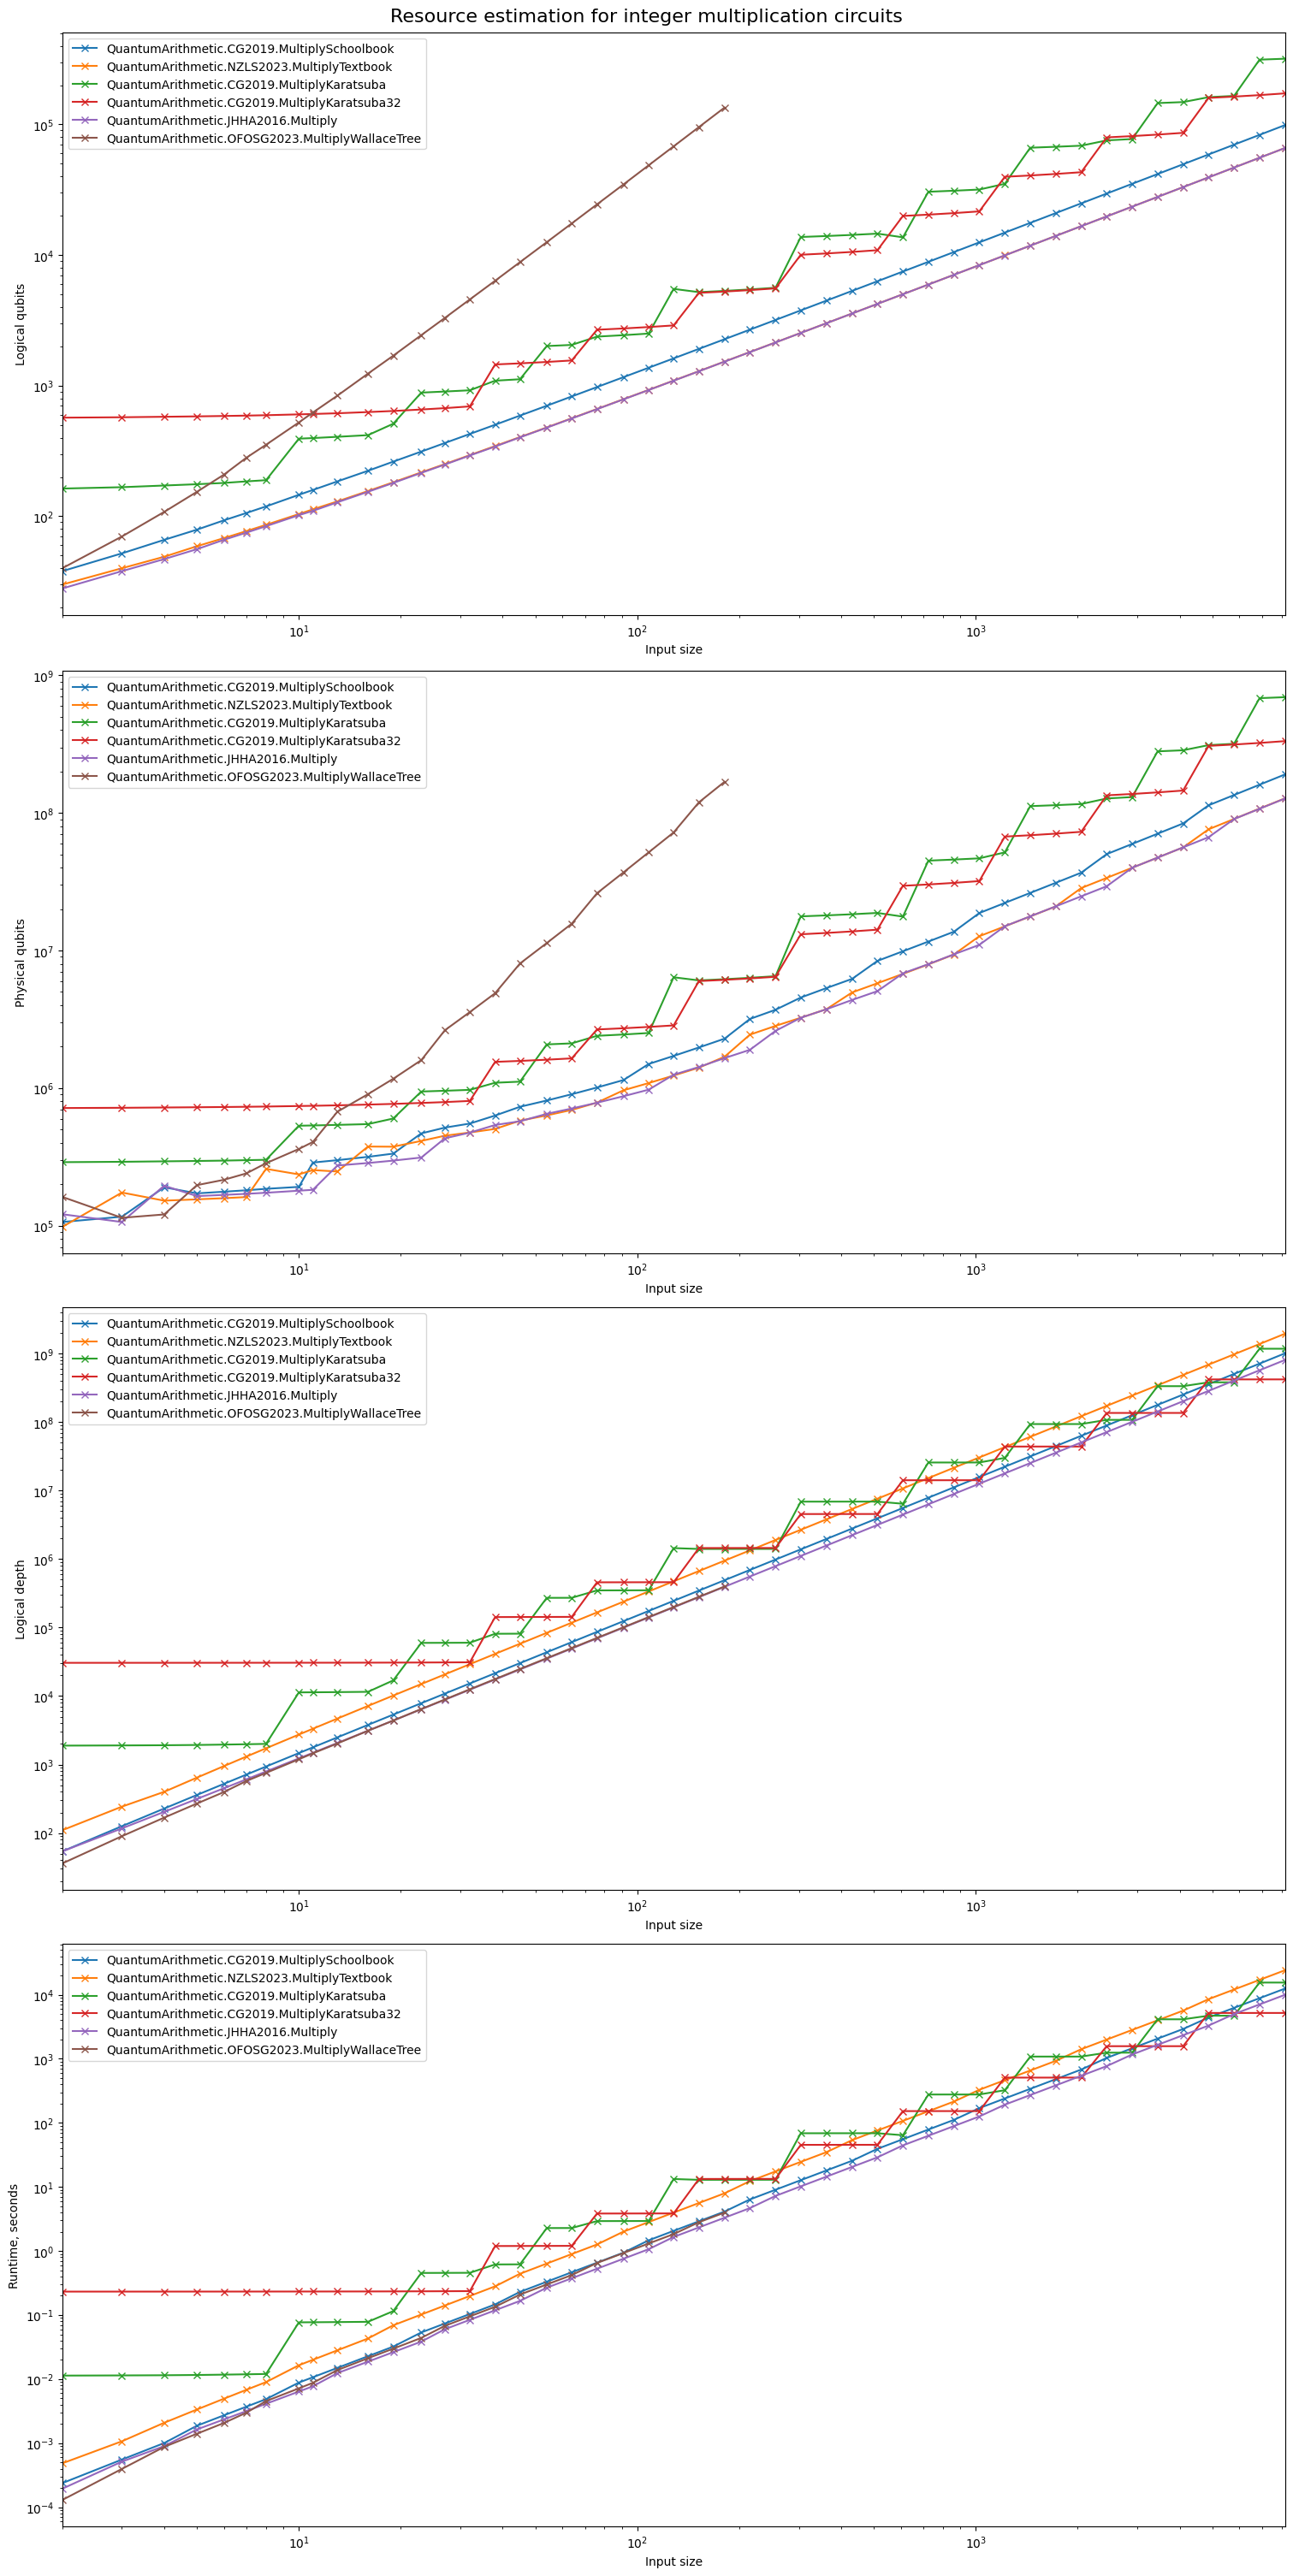

In [4]:
ops = [
  "QuantumArithmetic.CG2019.MultiplySchoolbook",
  "QuantumArithmetic.NZLS2023.MultiplyTextbook",
  "QuantumArithmetic.CG2019.MultiplyKaratsuba",
  "QuantumArithmetic.CG2019.MultiplyKaratsuba32",  
  "QuantumArithmetic.JHHA2016.Multiply",  
  "QuantumArithmetic.OFOSG2023.MultiplyWallaceTree",  
]

small_n_range = [2,3] + [int(round(2**(0.25*i))) for i in range(8,31)]
default_n_range = [2,3] + [int(round(2**(0.25*i))) for i in range(8,53)]
n_ranges = {op: default_n_range for op in ops}
n_ranges["QuantumArithmetic.OFOSG2023.MultiplyWallaceTree"] = small_n_range

metrics = ["Logical qubits", "Physical qubits", "Logical depth", "Runtime, seconds"]
charts = [{op: [] for op in ops} for _ in range(len(metrics))]

for op in ops:
    for n in n_ranges[op]:
        t0=time.time()
        estimates = json.loads(estimate_resources_multiply(op, n))
        print(n, op, time.time()-t0, flush=True)
        charts[0][op].append(estimates['physicalCounts']['breakdown']['algorithmicLogicalQubits'])
        charts[1][op].append(estimates['physicalCounts']['physicalQubits'])
        charts[2][op].append(estimates['physicalCounts']['breakdown']['logicalDepth'])
        charts[3][op].append(estimates['physicalCounts']['runtime']/10**9)
        
    
fig, ax = plt.subplots(figsize=(15, 30), nrows=len(metrics), ncols=1, constrained_layout=True)
for i in range(len(metrics)):
    for op in ops:
        ax[i].plot(n_ranges[op], charts[i][op], label=op, marker='x')
    ax[i].set_xlim([2,max(max(n_ranges[op]) for op in ops)])
    ax[i].legend()
    ax[i].set_xlabel('Input size')
    ax[i].set_ylabel(metrics[i])
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
fig.suptitle("Resource estimation for integer multiplication circuits", fontsize=16)
plt.show()